In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# from scipy.interpolate import RegularGridInterpolator
import MITgcmutils as mitgcm
import xmitgcm 
from xmitgcm.utils import read_mds
from matplotlib.path import Path

%matplotlib inline
import os
import imageio
import pandas as pd

import sys
from contextlib import contextmanager

import ttide as tt
from tqdm import tqdm
import psutil
import math
import gc

# for out diag files

In [2]:
def get_ram_info():
    """
    Retrieves and prints detailed information about the system's RAM usage.
    """
    mem = psutil.virtual_memory()
    
    # Helper function to format bytes into human-readable units (GB)
    bytes_to_gb = lambda bytes_val: math.ceil(bytes_val / (1024**3))

    # print(f"Total RAM      : {bytes_to_gb(mem.total)} GB")
    # print(f"Available RAM  : {bytes_to_gb(mem.available)} GB")
    print(f"Used RAM  : {mem.used}")
    # print(f"Used RAM       : {bytes_to_gb(mem.used)} GB")
    # print(f"Used Percentage: {mem.percent}%")

get_ram_info()

Used RAM  : 9445650432


In [3]:
drF = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/DRF',)
hFacW = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/hFacW',)
hFacS = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/hFacS',)
XC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/XC',)
XG = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/XG',)
YC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/YC',)
RC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/RC',)
Depth = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/Depth',)
maskC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/maskInC',)

rho0 = 1025  # kg/m3

In [4]:
polygon2 = np.array([
                    [122.4156305555556,7.857713888888888],
                    [122.0628562951826,6.950772011696411],
                    [122.0604127462074,6.418861725702965],
                    [120.7759136579978,5.474645071467973],
                    [119.7477305555556,5.019866666666666],
                    [119.0369305555556,5.263388888888889],
                    [117.4610027777778,5.793652777777778],
                    [116.8239415753721,4.373865718248119],
                    [116.9949675073274,1.558713512219585],
                    [120.3555390294262,0.5651467190202299], 
                    [123.4819050887947,0.6174487079475919],
                    [124.3362386703296,0.7218080110272068], 
                    [125.0459513736719,1.56049707444234], 
                    [125.5646347020307,3.624570421021212], 
                    [125.4348070923769,5.731009669433583], 
                    [125.0783145681645,7.287851725018649], 
                    [123.2758350270172,8.171442179663259], 
                    [122.4156305555556,7.857713888888888],
                    ])
polygon3 = np.array([
                    # [116.9591218380855,1.536846264008097],
                    [116.9949675073274,1.558713512219585],
                    [114.9619987677299,-3.295],
                    [119.5759922476142,-3.295] ,
                    [120.050971940272,-1.123578926929182],
                    [119.9073612391546,-0.448856717406894],
                    # [120.279550722386,0.5528591718648243],
                    [120.0183333333333,0.2],
                    [120.3555390294262,0.5651467190202299], 
                    [116.9949675073274,1.558713512219585]
                    # [116.9591218380855,1.536846264008097]
                    ])

100%|██████████| 1908/1908 [00:13<00:00, 144.83it/s]


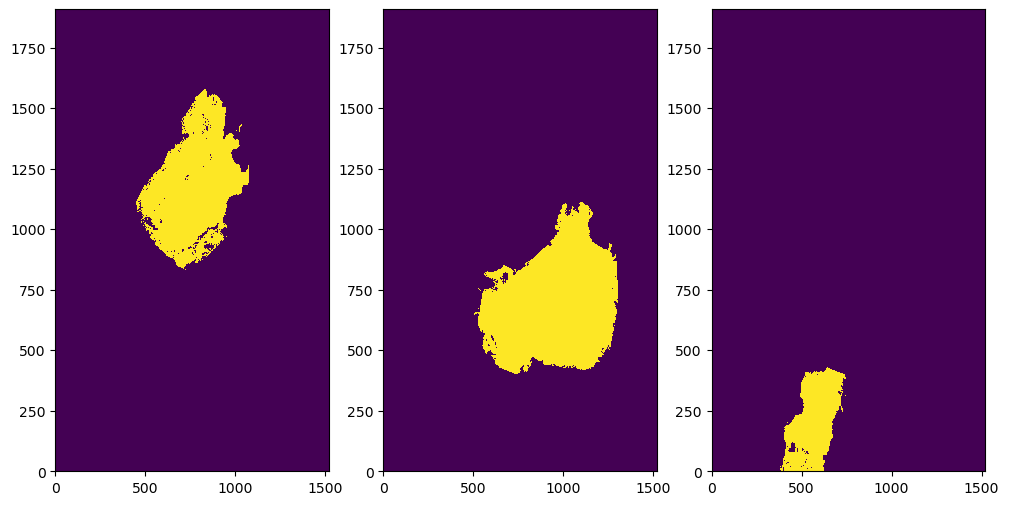

In [5]:
## create mask for the 3 basins
# mask_sulu = np.zeros(Depth['Depth'].shape)
# mask_sulu[(XC>=116) & (XC<=126) & (YC>=5) & (YC<=15)] = 1

# 4. Define a mask for the Sulu Sea region
mask_sulu = np.zeros_like(maskC['maskInC'].compute())
mask_cele = np.zeros_like(maskC['maskInC'].compute())
mask_maka = np.zeros_like(maskC['maskInC'].compute())
lon = XC['XC'].compute()
lat = YC['YC'].compute()
mask_sea = maskC['maskInC'].compute()
depth_sea = Depth['Depth'].compute()
# Define the polygon vertices for the Sulu Sea region
polygon = np.array([[119.7477305555556,5.019866666666666],
                    [120.7759136579978,5.474645071467973],
                    [122.0604127462074,6.418861725702965],
                    [122.0628562951826,6.950772011696411],
                    [122.4156305555556,7.857713888888888],
                    [123.2841972222222,8.224422222222222],
                    [123.2738388888889,9.305238888888889],
                    [123.0141444444444,9.580508333333334],
                    [123.2125075318087,10.77780565549861],
                    [121.9560470708515,11.85454899091673],
                    [120.9629975202234,12.58813464766382],
                    [120.2369776182294,12.10162143969847],
                    [119.9644441358147,11.66278768318502],
                    [119.4982072167793,11.19294905649988],
                    [119.5408523724053,10.66721177108409],
                    [117.7072365775101,8.913243570406612],
                    [116.9942048191374,7.818840574887203],
                    [117.0953880245524,7.260348599583542],
                    [117.4610027777778,5.793652777777778],
                    [119.0369305555556,5.263388888888889],
                    [119.7477305555556,5.019866666666666]
])

min_depth=20

path = Path(polygon)
path2 = Path(polygon2) # celebes
path3 = Path(polygon3) # makassar
for i in tqdm(range(mask_sulu.shape[0])):
    for j in range(mask_sulu.shape[1]):
        if path.contains_point((lon[i, j], lat[i, j])):
            mask_sulu[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_sulu[i, j] = 0
        if path2.contains_point((lon[i, j], lat[i, j])):
            mask_cele[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_cele[i, j] = 0
        if path3.contains_point((lon[i, j], lat[i, j])):
            mask_maka[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_maka[i, j] = 0
fig, ax = plt.subplots(1,3,figsize=(12,6))
ax[0].pcolormesh(mask_sulu)
# plt.figure(figsize=(6,8))
ax[1].pcolormesh(mask_cele)
# plt.figure(figsize=(6,8))
ax[2].pcolormesh(mask_maka)

## read and calculate depth-averaged u/v (barotropic) from ctrl case

In [4]:
for im in range(5):
    u_ts = []
    get_ram_info()
    it1 = im*100
    it2 = (im+1)*100
    for it in range(it1,it2):
        print(f'Processing time step: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        # u_ts.append(u['UVEL'][:,1000,700])
        u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
        u_ts.append(u2d_2)

    # convert u_ts to xarray dataset and save as netcdf
    u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
    u_ts_da.to_netcdf(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Used RAM  : 9852805120
Processing time step: 0
Processing time step: 1
Processing time step: 2
Processing time step: 3
Processing time step: 4
Processing time step: 5
Processing time step: 6
Processing time step: 7
Processing time step: 8
Processing time step: 9
Processing time step: 10
Processing time step: 11
Processing time step: 12
Processing time step: 13
Processing time step: 14
Processing time step: 15
Processing time step: 16
Processing time step: 17
Processing time step: 18
Processing time step: 19
Processing time step: 20
Processing time step: 21
Processing time step: 22
Processing time step: 23
Processing time step: 24
Processing time step: 25
Processing time step: 26
Processing time step: 27
Processing time step: 28
Processing time step: 29
Processing time step: 30
Processing time step: 31
Processing time step: 32
Processing time step: 33
Processing time step: 34
Processing time step: 35
Processing time step: 36
Processing time step: 37
Processing time step: 38
Processing t

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11671859200
Processing time step: 100
Processing time step: 101
Processing time step: 102
Processing time step: 103
Processing time step: 104
Processing time step: 105
Processing time step: 106
Processing time step: 107
Processing time step: 108
Processing time step: 109
Processing time step: 110
Processing time step: 111
Processing time step: 112
Processing time step: 113
Processing time step: 114
Processing time step: 115
Processing time step: 116
Processing time step: 117
Processing time step: 118
Processing time step: 119
Processing time step: 120
Processing time step: 121
Processing time step: 122
Processing time step: 123
Processing time step: 124
Processing time step: 125
Processing time step: 126
Processing time step: 127
Processing time step: 128
Processing time step: 129
Processing time step: 130
Processing time step: 131
Processing time step: 132
Processing time step: 133
Processing time step: 134
Processing time step: 135
Processing time step: 136
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11456208896
Processing time step: 200
Processing time step: 201
Processing time step: 202
Processing time step: 203
Processing time step: 204
Processing time step: 205
Processing time step: 206
Processing time step: 207
Processing time step: 208
Processing time step: 209
Processing time step: 210
Processing time step: 211
Processing time step: 212
Processing time step: 213
Processing time step: 214
Processing time step: 215
Processing time step: 216
Processing time step: 217
Processing time step: 218
Processing time step: 219
Processing time step: 220
Processing time step: 221
Processing time step: 222
Processing time step: 223
Processing time step: 224
Processing time step: 225
Processing time step: 226
Processing time step: 227
Processing time step: 228
Processing time step: 229
Processing time step: 230
Processing time step: 231
Processing time step: 232
Processing time step: 233
Processing time step: 234
Processing time step: 235
Processing time step: 236
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11603496960
Processing time step: 300
Processing time step: 301
Processing time step: 302
Processing time step: 303
Processing time step: 304
Processing time step: 305
Processing time step: 306
Processing time step: 307
Processing time step: 308
Processing time step: 309
Processing time step: 310
Processing time step: 311
Processing time step: 312
Processing time step: 313
Processing time step: 314
Processing time step: 315
Processing time step: 316
Processing time step: 317
Processing time step: 318
Processing time step: 319
Processing time step: 320
Processing time step: 321
Processing time step: 322
Processing time step: 323
Processing time step: 324
Processing time step: 325
Processing time step: 326
Processing time step: 327
Processing time step: 328
Processing time step: 329
Processing time step: 330
Processing time step: 331
Processing time step: 332
Processing time step: 333
Processing time step: 334
Processing time step: 335
Processing time step: 336
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11592658944
Processing time step: 400
Processing time step: 401
Processing time step: 402
Processing time step: 403
Processing time step: 404
Processing time step: 405
Processing time step: 406
Processing time step: 407
Processing time step: 408
Processing time step: 409
Processing time step: 410
Processing time step: 411
Processing time step: 412
Processing time step: 413
Processing time step: 414
Processing time step: 415
Processing time step: 416
Processing time step: 417
Processing time step: 418
Processing time step: 419
Processing time step: 420
Processing time step: 421
Processing time step: 422
Processing time step: 423
Processing time step: 424
Processing time step: 425
Processing time step: 426
Processing time step: 427
Processing time step: 428
Processing time step: 429
Processing time step: 430
Processing time step: 431
Processing time step: 432
Processing time step: 433
Processing time step: 434
Processing time step: 435
Processing time step: 436
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [5]:
# v_ts = []

for im in range(5):
    v_ts = []
    get_ram_info()
    it1 = im*100
    it2 = (im+1)*100
    for it in range(it1,it2):
        print(f'Processing time step: {it}')
        itt = it*180
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        # v_ts.append(v['VVEL'][:,1000,700])
        v2d_2 = np.nansum(v['VVEL']*drF['DRF']*hFacS['hFacS'], axis=0)/np.nansum(drF['DRF']*hFacS['hFacS'], axis=0)
        v_ts.append(v2d_2)

    # convert v_ts to xarray dataset and save as netcdf
    v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
    v_ts_da.to_netcdf(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')

# for it in range(500,530):
#     print(f'Processing time step: {it}')
#     itt = it*180
#     v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
#     # v_ts.append(v['VVEL'][:,1000,700])
#     v2d_2 = np.nansum(v['VVEL']*drF['DRF']*hFacS['hFacS'], axis=0)/np.nansum(drF['DRF']*hFacS['hFacS'], axis=0)
#     v_ts.append(v2d_2)

# # convert v_ts to xarray dataset and save as netcdf
# v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
# v_ts_da.to_netcdf('case_ctrl/v_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(v2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Used RAM  : 12250374144
Processing time step: 0
Processing time step: 1
Processing time step: 2
Processing time step: 3
Processing time step: 4
Processing time step: 5
Processing time step: 6
Processing time step: 7
Processing time step: 8
Processing time step: 9
Processing time step: 10
Processing time step: 11
Processing time step: 12
Processing time step: 13
Processing time step: 14
Processing time step: 15
Processing time step: 16
Processing time step: 17
Processing time step: 18
Processing time step: 19
Processing time step: 20
Processing time step: 21
Processing time step: 22
Processing time step: 23
Processing time step: 24
Processing time step: 25
Processing time step: 26
Processing time step: 27
Processing time step: 28
Processing time step: 29
Processing time step: 30
Processing time step: 31
Processing time step: 32
Processing time step: 33
Processing time step: 34
Processing time step: 35
Processing time step: 36
Processing time step: 37
Processing time step: 38
Processing 

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12555194368
Processing time step: 100
Processing time step: 101
Processing time step: 102
Processing time step: 103
Processing time step: 104
Processing time step: 105
Processing time step: 106
Processing time step: 107
Processing time step: 108
Processing time step: 109
Processing time step: 110
Processing time step: 111
Processing time step: 112
Processing time step: 113
Processing time step: 114
Processing time step: 115
Processing time step: 116
Processing time step: 117
Processing time step: 118
Processing time step: 119
Processing time step: 120
Processing time step: 121
Processing time step: 122
Processing time step: 123
Processing time step: 124
Processing time step: 125
Processing time step: 126
Processing time step: 127
Processing time step: 128
Processing time step: 129
Processing time step: 130
Processing time step: 131
Processing time step: 132
Processing time step: 133
Processing time step: 134
Processing time step: 135
Processing time step: 136
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12511596544
Processing time step: 200
Processing time step: 201
Processing time step: 202
Processing time step: 203
Processing time step: 204
Processing time step: 205
Processing time step: 206
Processing time step: 207
Processing time step: 208
Processing time step: 209
Processing time step: 210
Processing time step: 211
Processing time step: 212
Processing time step: 213
Processing time step: 214
Processing time step: 215
Processing time step: 216
Processing time step: 217
Processing time step: 218
Processing time step: 219
Processing time step: 220
Processing time step: 221
Processing time step: 222
Processing time step: 223
Processing time step: 224
Processing time step: 225
Processing time step: 226
Processing time step: 227
Processing time step: 228
Processing time step: 229
Processing time step: 230
Processing time step: 231
Processing time step: 232
Processing time step: 233
Processing time step: 234
Processing time step: 235
Processing time step: 236
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12548984832
Processing time step: 300
Processing time step: 301
Processing time step: 302
Processing time step: 303
Processing time step: 304
Processing time step: 305
Processing time step: 306
Processing time step: 307
Processing time step: 308
Processing time step: 309
Processing time step: 310
Processing time step: 311
Processing time step: 312
Processing time step: 313
Processing time step: 314
Processing time step: 315
Processing time step: 316
Processing time step: 317
Processing time step: 318
Processing time step: 319
Processing time step: 320
Processing time step: 321
Processing time step: 322
Processing time step: 323
Processing time step: 324
Processing time step: 325
Processing time step: 326
Processing time step: 327
Processing time step: 328
Processing time step: 329
Processing time step: 330
Processing time step: 331
Processing time step: 332
Processing time step: 333
Processing time step: 334
Processing time step: 335
Processing time step: 336
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12686221312
Processing time step: 400
Processing time step: 401
Processing time step: 402
Processing time step: 403
Processing time step: 404
Processing time step: 405
Processing time step: 406
Processing time step: 407
Processing time step: 408
Processing time step: 409
Processing time step: 410
Processing time step: 411
Processing time step: 412
Processing time step: 413
Processing time step: 414
Processing time step: 415
Processing time step: 416
Processing time step: 417
Processing time step: 418
Processing time step: 419
Processing time step: 420
Processing time step: 421
Processing time step: 422
Processing time step: 423
Processing time step: 424
Processing time step: 425
Processing time step: 426
Processing time step: 427
Processing time step: 428
Processing time step: 429
Processing time step: 430
Processing time step: 431
Processing time step: 432
Processing time step: 433
Processing time step: 434
Processing time step: 435
Processing time step: 436
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## read and calculate depth-averaged usur from barotropic case

In [71]:
u_ts = []

for it in range(500,530):
    print(f'Processing time step for BT case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['UVEL'][0,:,:]
    u_ts.append(u2d_2)

# convert u_ts to xarray dataset and save as netcdf
u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BT case: 500
Processing time step for BT case: 501
Processing time step for BT case: 502
Processing time step for BT case: 503
Processing time step for BT case: 504
Processing time step for BT case: 505
Processing time step for BT case: 506
Processing time step for BT case: 507
Processing time step for BT case: 508
Processing time step for BT case: 509
Processing time step for BT case: 510
Processing time step for BT case: 511
Processing time step for BT case: 512
Processing time step for BT case: 513
Processing time step for BT case: 514
Processing time step for BT case: 515
Processing time step for BT case: 516
Processing time step for BT case: 517
Processing time step for BT case: 518
Processing time step for BT case: 519
Processing time step for BT case: 520
Processing time step for BT case: 521
Processing time step for BT case: 522
Processing time step for BT case: 523
Processing time step for BT case: 524
Processing time step for BT case: 525
Processing t

In [13]:
v_ts = []

for it in range(500,530):
    print(f'Processing time step for BT case: {it}')
    itt = it*180
    v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
    v2d_2 = v['VVEL'][0,:,:]
    v_ts.append(v2d_2)
# convert v_ts to xarray dataset and save as netcdf
v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
v_ts_da.to_netcdf('case_barotropic/v_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(v2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BT case: 500
Processing time step for BT case: 501
Processing time step for BT case: 502
Processing time step for BT case: 503
Processing time step for BT case: 504
Processing time step for BT case: 505
Processing time step for BT case: 506
Processing time step for BT case: 507
Processing time step for BT case: 508
Processing time step for BT case: 509
Processing time step for BT case: 510
Processing time step for BT case: 511
Processing time step for BT case: 512
Processing time step for BT case: 513
Processing time step for BT case: 514
Processing time step for BT case: 515
Processing time step for BT case: 516
Processing time step for BT case: 517
Processing time step for BT case: 518
Processing time step for BT case: 519
Processing time step for BT case: 520
Processing time step for BT case: 521
Processing time step for BT case: 522
Processing time step for BT case: 523
Processing time step for BT case: 524
Processing time step for BT case: 525
Processing t

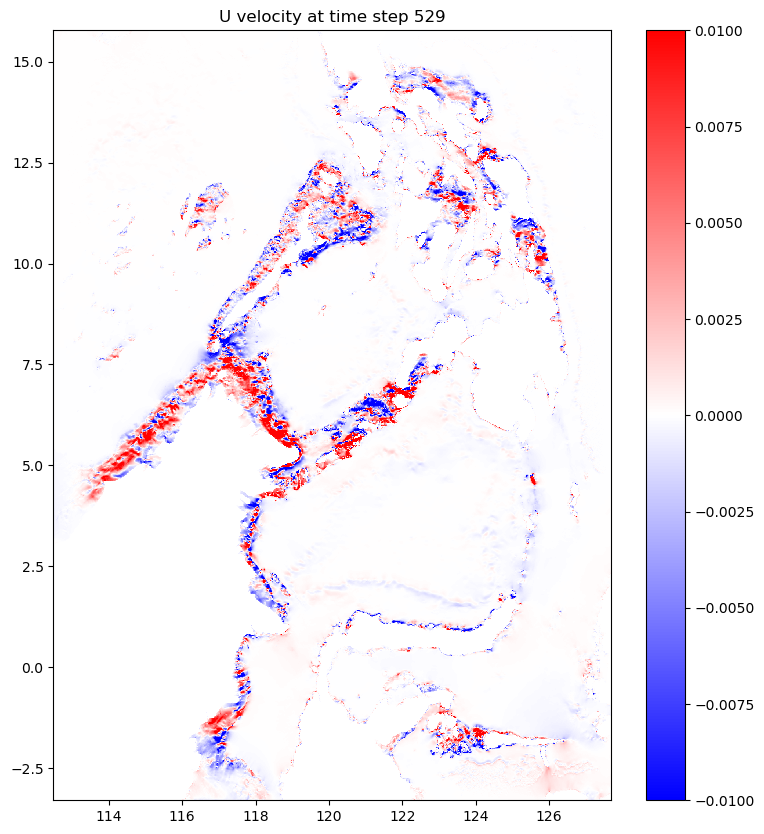

In [66]:
#check saved netcdf
ds_check = xr.open_dataset('case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_check['__xarray_dataarray_variable__']

fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for i in range(30):
    ax.clear()
    cs = ax.pcolormesh(ds_bt.XG, ds_bt.YC, ds_check['__xarray_dataarray_variable__'].isel(time=i),vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'U velocity at time step {500+i}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/u_2d_frombc_t_500_to_530_{i}.png')


In [74]:
fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for it in range(500,530):
    print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['UVEL'][0,:,:]
    # u_ts.append(u2d_2)

    ax.clear()
    cs = ax.pcolormesh(ds_bt.XG, ds_bt.YC, u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'Usur velocity at time step {it}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/usur_frombc_t_500_to_530_{it}.png')
# # convert u_ts to xarray dataset and save as netcdf
# u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
# u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BC case: 500
Processing time step for BC case: 501
Processing time step for BC case: 502
Processing time step for BC case: 503
Processing time step for BC case: 504
Processing time step for BC case: 505
Processing time step for BC case: 506
Processing time step for BC case: 507
Processing time step for BC case: 508
Processing time step for BC case: 509
Processing time step for BC case: 510
Processing time step for BC case: 511
Processing time step for BC case: 512
Processing time step for BC case: 513
Processing time step for BC case: 514
Processing time step for BC case: 515
Processing time step for BC case: 516
Processing time step for BC case: 517
Processing time step for BC case: 518
Processing time step for BC case: 519
Processing time step for BC case: 520
Processing time step for BC case: 521
Processing time step for BC case: 522
Processing time step for BC case: 523
Processing time step for BC case: 524
Processing time step for BC case: 525
Processing t

: 

: 

: 

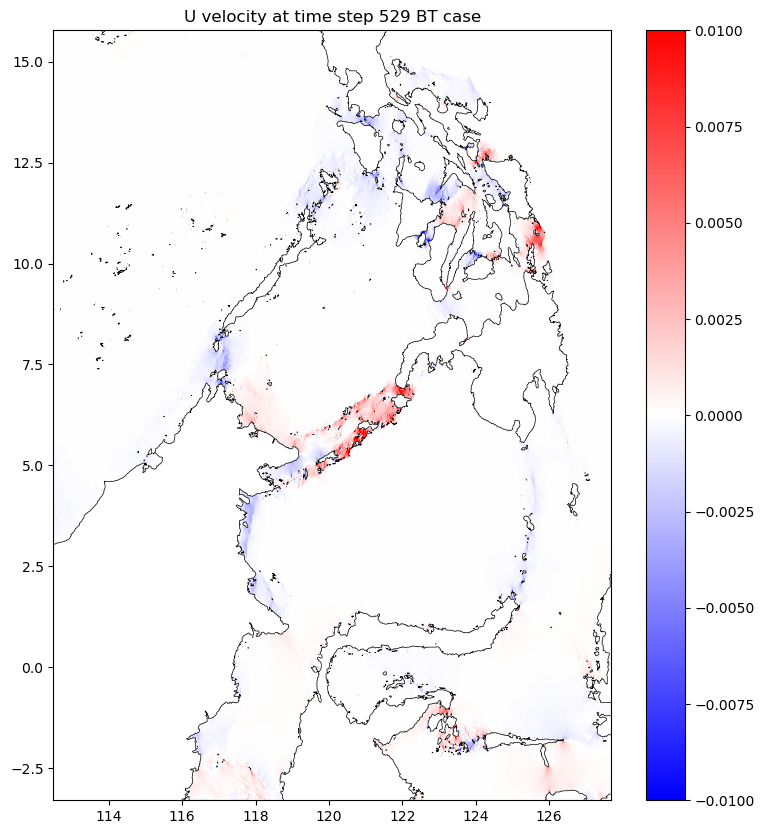

In [11]:
#check saved netcdf
ds_check = xr.open_dataset('case_barotropic/u_2d_frombc_t_500_to_530.nc')
ds_check['__xarray_dataarray_variable__']

fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for i in range(30):
    ax.clear()
    var_plt = ds_check['__xarray_dataarray_variable__'].isel(time=i)
    var_plt = var_plt.where(var_plt != 0)
    cs = ax.pcolormesh(XG['XG'], YC['YC'], var_plt,vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    ax.contour(XG['XG'].compute(), YC['YC'].compute(), hFacW['hFacW'][0].compute(), levels=[0], colors='k', linewidths=0.5)
    
    ax.set_title(f'U velocity at time step {500+i} BT case')
    # plt.pause(0.5)

    plt.savefig(f'case_barotropic/u_2d_frombc_t_500_to_530_{i}.png')


Processing time step for BC case: 500


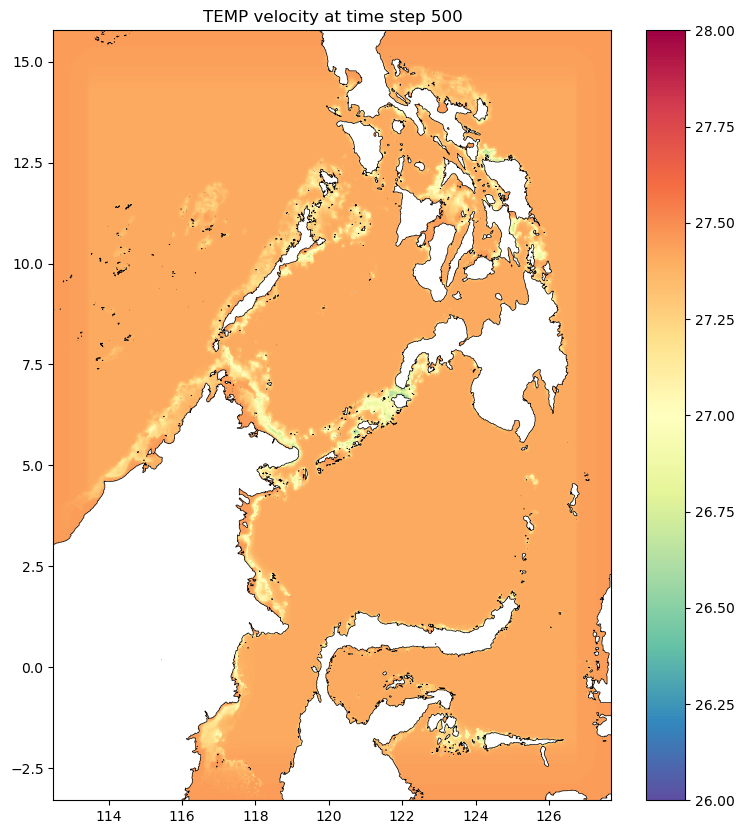

In [15]:
fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for it in range(500,501):
    print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['THETA'][0,:,:]

    # u_ts.append(u2d_2)
    u2d_2[u2d_2==0]=np.nan
    ax.clear()
    cs = ax.pcolormesh(XC['XC'], YC['YC'], u2d_2,vmax=28, vmin=26,cmap='Spectral_r')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    ax.contour(XG['XG'].compute(), YC['YC'].compute(), hFacW['hFacW'][0].compute(), levels=[0], colors='k', linewidths=0.5)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'TEMP velocity at time step {it}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/tsur_frombc_t_500_to_530_{it}.png')
# # convert u_ts to xarray dataset and save as netcdf
# u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
# u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

In [1]:
plt.pcolormesh(XC['XC'], YC['YC'], u2d_2,vmax=28, vmin=26,cmap='Spectral_r')
plt.xlim(116,122)
plt.ylim(5,8)
plt.hlines(5.705,118.3,119)
plt.colorbar()
plt.title('TEMP at time step 500')

NameError: name 'plt' is not defined

In [60]:
YC['YC'][900,0].compute()

5.705

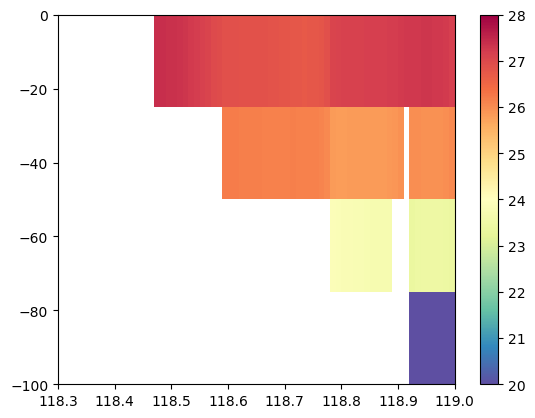

In [63]:
# np.array(YC['YC'][900,0])

# np.array(XC['XC'][0,850])

xp = XC['XC'][0,550:850]
yp = RC['RC'][:,0,0]
varp = u['THETA'][:,900,550:850]
varp = np.where(varp != 0, varp, np.nan)
# plt.contourf(xp, yp,  varp,vmax=28, vmin=15,cmap='Spectral_r',levels=np.arange(15,29,0.2))
plt.pcolormesh(xp, yp,  varp, vmax=28, vmin=20, cmap='Spectral_r')
plt.ylim(-100,0)
plt.xlim(118.3,119)
plt.colorbar()



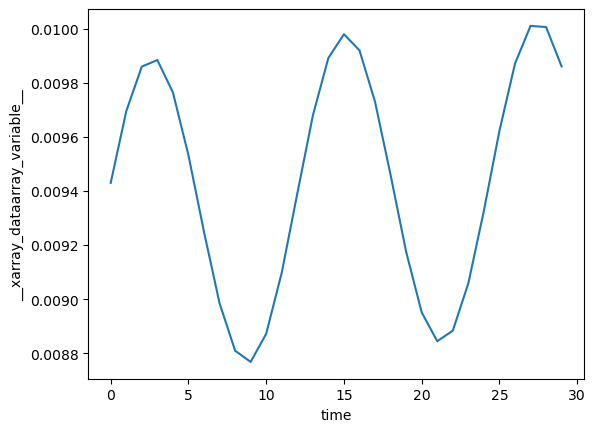

In [69]:
ds_check['__xarray_dataarray_variable__'].isel(XG=600, YC=900).plot()

## Calculate ENERGY
### should be done in 3 steps, (1) KE of barotropic test, (2) KE of BT enery of ctrl case, (3) KE BC energy of ctrl case 

### step 1. KE of barotropic case

In [ ]:
### step 1. ke of the barotropic case at time step 500
ds_bt_u = xr.open_dataset('case_barotropic/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset('case_barotropic/v_2d_frombc_t_500_to_530.nc')

ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth']* rho0

In [ ]:
# ke_bt_tseries = []
ke_bt_tseries_hsum = []
ke_bt_tseries_sulu = []
ke_bt_tseries_cele = []
ke_bt_tseries_maka = []
for im in range(5):
    print(im)
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')
    ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                 + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
    ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
    ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
    ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
    ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
    ke_bt_tseries_hsum.append(ke_bt_hsum)
    ke_bt_tseries_sulu.append(ke_bt_sulu)
    ke_bt_tseries_cele.append(ke_bt_cele)
    ke_bt_tseries_maka.append(ke_bt_maka)
    get_ram_info()
ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_500_to_530.nc')
ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
ke_bt_tseries_hsum.append(ke_bt_hsum)
ke_bt_tseries_sulu.append(ke_bt_sulu)
ke_bt_tseries_cele.append(ke_bt_cele)
ke_bt_tseries_maka.append(ke_bt_maka)

ke_bt_tseries_hsum = np.concatenate(ke_bt_tseries_hsum)
ke_bt_tseries_sulu = np.concatenate(ke_bt_tseries_sulu)
ke_bt_tseries_cele = np.concatenate(ke_bt_tseries_cele)
ke_bt_tseries_maka = np.concatenate(ke_bt_tseries_maka)



0
Used RAM  : 13808123904
1
Used RAM  : 13950730240
2
Used RAM  : 14017880064
3
Used RAM  : 14005997568
4
Used RAM  : 13963747328


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (6,) + inhomogeneous part.

In [13]:
# save all the energy terms to a csv file
df_ke = pd.DataFrame({
    'ke_bt_total': ke_bt_tseries_hsum,
    'ke_bt_sulu': ke_bt_tseries_sulu,
    'ke_bt_cele': ke_bt_tseries_cele,
    'ke_bt_maka': ke_bt_tseries_maka,
})
df_ke.to_csv('ke_bt_time_series.csv', index=False) 

Text(0, 0.5, 'Kinetic Energy (J)')

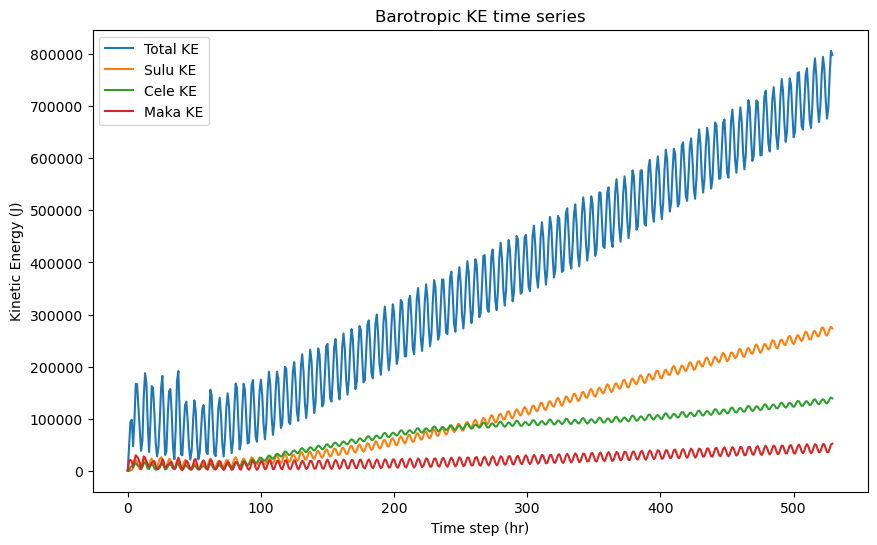

In [12]:
plt.figure(figsize=(10,6))
plt.plot(ke_bt_tseries_hsum, label='Total KE')
plt.plot(ke_bt_tseries_sulu, label='Sulu KE')
plt.plot(ke_bt_tseries_cele, label='Cele KE')
plt.plot(ke_bt_tseries_maka, label='Maka KE')
plt.legend()
plt.title('Barotropic KE time series')
plt.xlabel('Time step (hr)')
plt.ylabel('Kinetic Energy (J)')

In [32]:
## calculate Baroclinic KE
ke_bc_tseries_hsum = []
ke_bc_tseries_sulu = []
ke_bc_tseries_cele = []
ke_bc_tseries_maka = []

for im in range(5):
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')
    get_ram_info()
    u2d = ds_bt_u['__xarray_dataarray_variable__'].values
    v2d = ds_bt_v['__xarray_dataarray_variable__'].values
    for it in tqdm(range(it1, it2)):
        # print(f'Processing time step for BC case: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

        ubc = u['UVEL'].compute() - u2d[it-it1]
        vbc = v['VVEL'].compute() - v2d[it-it1]

        ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
        ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
        ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
        ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
        ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
        ke_bc_tseries_hsum.append(ke_bc_hsum)
        ke_bc_tseries_sulu.append(ke_bc_sulu)
        ke_bc_tseries_cele.append(ke_bc_cele)
        ke_bc_tseries_maka.append(ke_bc_maka)


Used RAM  : 15732441088


100%|██████████| 100/100 [10:22<00:00,  6.23s/it]


Used RAM  : 13871513600


100%|██████████| 100/100 [10:27<00:00,  6.27s/it]


Used RAM  : 13897498624


100%|██████████| 100/100 [10:52<00:00,  6.53s/it]


Used RAM  : 13880844288


100%|██████████| 100/100 [12:02<00:00,  7.23s/it]


Used RAM  : 14127710208


100%|██████████| 100/100 [11:24<00:00,  6.85s/it]


In [40]:
ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_500_to_530.nc')
get_ram_info()
u2d = ds_bt_u['__xarray_dataarray_variable__'].values
v2d = ds_bt_v['__xarray_dataarray_variable__'].values
for it in tqdm(range(500, 530)):
    # print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

    ubc = u['UVEL'].compute() - u2d[it-500]
    vbc = v['VVEL'].compute() - v2d[it-500]

    ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
    ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
    ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
    ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
    ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
    ke_bc_tseries_hsum.append(ke_bc_hsum)
    ke_bc_tseries_sulu.append(ke_bc_sulu)
    ke_bc_tseries_cele.append(ke_bc_cele)
    ke_bc_tseries_maka.append(ke_bc_maka)

Used RAM  : 13760294912


100%|██████████| 30/30 [03:26<00:00,  6.87s/it]


Text(0, 0.5, 'Kinetic Energy (J)')

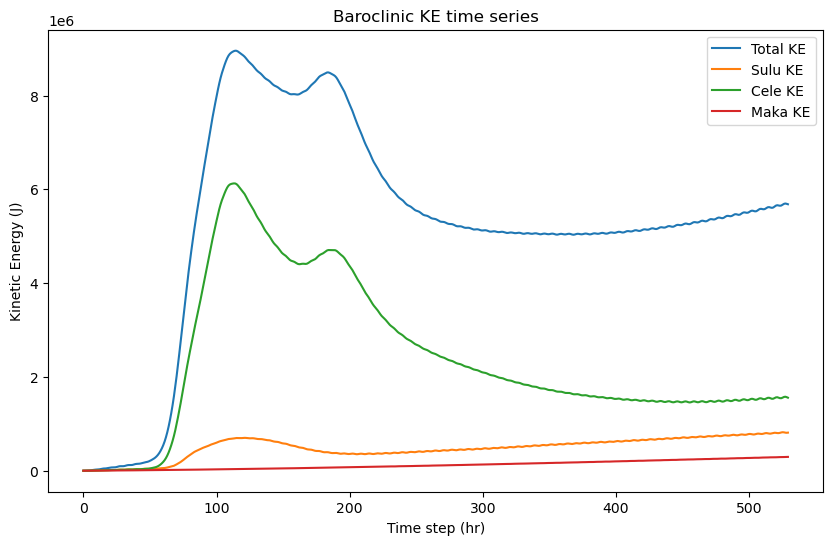

In [41]:
plt.figure(figsize=(10,6))
plt.plot(ke_bc_tseries_hsum, label='Total KE')
plt.plot(ke_bc_tseries_sulu, label='Sulu KE')
plt.plot(ke_bc_tseries_cele, label='Cele KE')
plt.plot(ke_bc_tseries_maka, label='Maka KE')
plt.legend()
plt.title('Baroclinic KE time series')
plt.xlabel('Time step (hr)')
plt.ylabel('Kinetic Energy (J)')
# plt.plot(ke_bt_tseries_hsum, label='Sulu KE')

In [39]:
# save all the energy terms to a csv file
df_ke = pd.DataFrame({
    'ke_bt_total': ke_bt_tseries_hsum,
    'ke_bt_sulu': ke_bt_tseries_sulu,
    'ke_bt_cele': ke_bt_tseries_cele,
    'ke_bt_maka': ke_bt_tseries_maka,
    'ke_bc_total': ke_bc_tseries_hsum,
    'ke_bc_sulu': ke_bc_tseries_sulu,
    'ke_bc_cele': ke_bc_tseries_cele,
    'ke_bc_maka': ke_bc_tseries_maka,
})
df_ke.to_csv('ke_time_series.csv', index=False) 

In [ ]:
## calculate total KE
ke_tseries_hsum = []
ke_tseries_sulu = []
ke_tseries_cele = []
ke_tseries_maka = []

for it in tqdm(500):
        # print(f'Processing time step for BC case: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

        ubc = u['UVEL'].compute() - u2d[it-it1]
        vbc = v['VVEL'].compute() - v2d[it-it1]

        ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
        ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
        ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
        ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
        ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
        ke_bc_tseries_hsum.append(ke_bc_hsum)
        ke_bc_tseries_sulu.append(ke_bc_sulu)
        ke_bc_tseries_cele.append(ke_bc_cele)
        ke_bc_tseries_maka.append(ke_bc_maka)


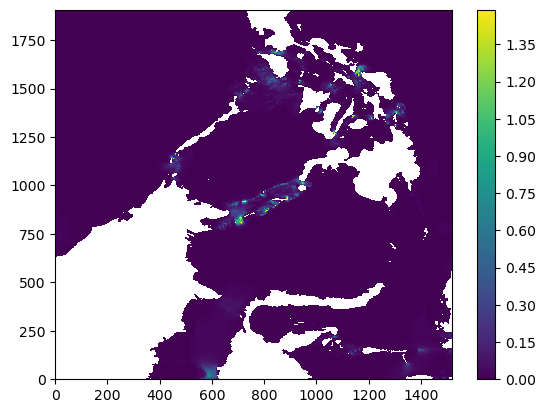

In [ ]:
ke_bt_0 = ke_bt[0,:,:]*maskC['maskInC'].compute()
ke_bt_0[ke_bt_0==0] = np.nan
plt.contourf(ke_bt_0,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.colorbar()

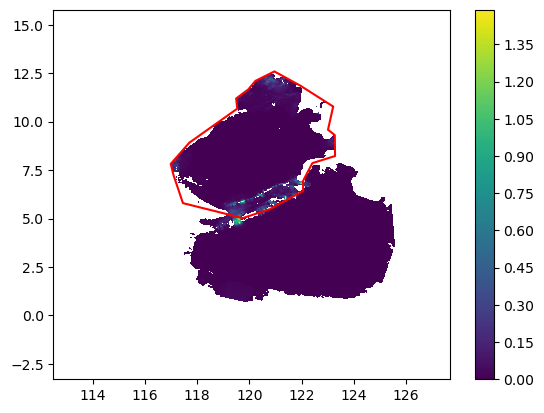

In [133]:
ke_bt_sulu = ke_bt[0,:,:]*mask_sulu
ke_bt_sulu[ke_bt_sulu==0] = np.nan
plt.contourf(lon,lat,ke_bt_sulu,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.plot(polygon[:,0],polygon[:,1],'-r')
plt.contourf(lon,lat,ke_bt_cele,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.colorbar()

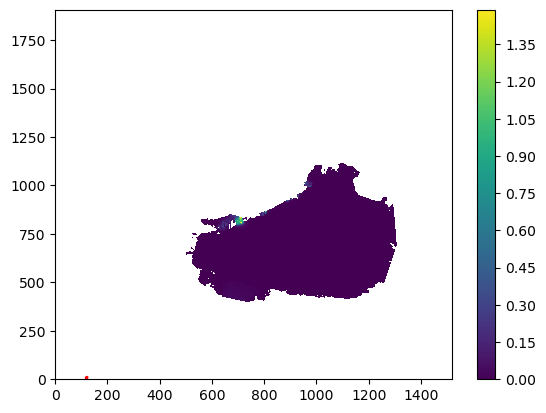

In [ ]:
ke_bt_cele = ke_bt[0,:,:]*mask_cele
ke_bt_cele[ke_bt_cele==0] = np.nan
plt.contourf(lon,lat,ke_bt_cele,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.plot(polygon[:,0],polygon[:,1],'-r')
# plt.contourf(ke_bt_sulu,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.colorbar()

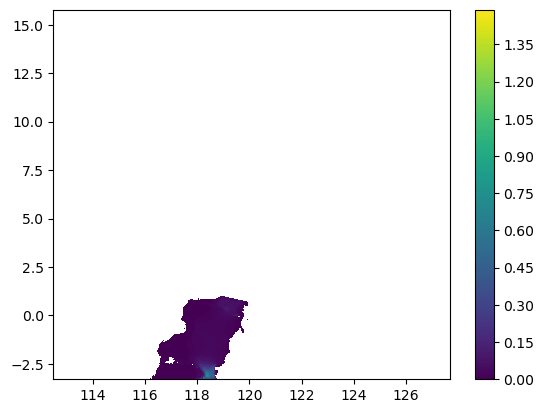

In [134]:
ke_bt_maka = ke_bt[0,:,:]*mask_maka
ke_bt_maka[ke_bt_maka==0] = np.nan
plt.contourf(lon,lat,ke_bt_maka,levels=np.arange(0,1.5,0.01),vmax=1.5)
# plt.plot(polygon[:,0],polygon[:,1],'-r')
# plt.contourf(ke_bt_sulu,levels=np.arange(0,1.5,0.01),vmax=1.5)
plt.colorbar()

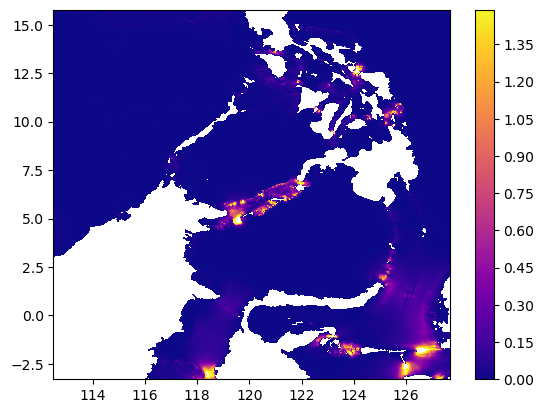

In [143]:
ke_bt_tavg = np.mean(ke_bt[0:24,:,:]*maskC['maskInC'].compute(),axis=0)

ke_bt_tavg[ke_bt_tavg==0] = np.nan
plt.contourf(lon,lat, ke_bt_tavg,levels=np.arange(0,1.5,0.01),vmax=1.5,cmap='plasma')
plt.colorbar()

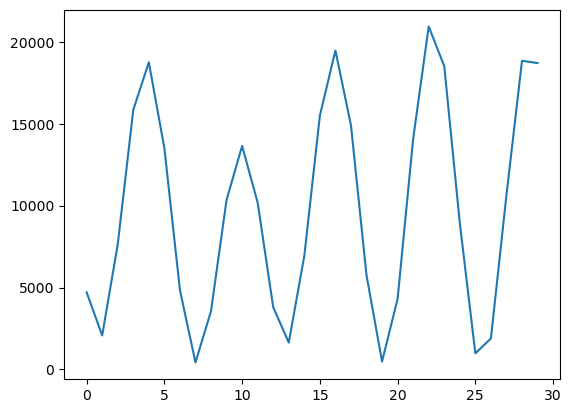

In [138]:
ke_sulu_tseries = np.sum(ke_bt*mask_sulu,axis=[1,2])

plt.plot(ke_sulu_tseries)

# OLD STUFF, should be deleted
# --- IGNORE ---

In [ ]:
icase = '075'

nt = 570


In [ ]:
ds_eta = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',prefix=['outs_sn_etan'])
# ds_eta

ds_sn = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',prefix=['outs_sn'])
ds_sn

<xarray.Dataset> Size: 2TB
Dimensions:  (XC: 1520, YC: 1908, XG: 1520, YG: 1908, Z: 57, Zp1: 58, Zu: 57,
              Zl: 57, time: 575)
Coordinates: (12/37)
  * XC       (XC) >f4 6kB 112.5 112.5 112.5 112.5 ... 127.7 127.7 127.7 127.7
  * YC       (YC) >f4 8kB -3.295 -3.285 -3.275 -3.265 ... 15.76 15.77 15.77
  * XG       (XG) >f4 6kB 112.5 112.5 112.5 112.5 ... 127.7 127.7 127.7 127.7
  * YG       (YG) >f4 8kB -3.3 -3.29 -3.28 -3.27 ... 15.74 15.75 15.76 15.77
  * Z        (Z) >f4 228B -12.5 -37.5 -62.5 ... -4.062e+03 -4.453e+03 -4.908e+03
  * Zp1      (Zp1) >f4 232B 0.0 -25.0 -50.0 ... -4.247e+03 -4.658e+03 -5.158e+03
    ...       ...
    maskInW  (YC, XG) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    dxF      (YC, XC) >f4 12MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    maskInC  (YC, XC) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    maskInS  (YG, XC) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    iter     (time) int64 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time     (time) timedelta64[ns] 5kB 00:00:00 00:03:00 ... 1 days 04:42:00
Data variables:
    UVEL     (time, Z, YC, XG) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    PHIHYD   (time, Z, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='/home/ceoas/l...

## 1. plot ETA and make GIF

In [ ]:
fig_folder = f'case_N2_fac_{icase}'
try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")

lon = ds_eta.XC
lat = ds_eta.YC

# t0 = diff_eta.time[0].values*10/np.timedelta64(1, 'h')

for it in range(0,33):
    # ds_eta = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1',iters = [it*10],prefix=['outs_sn_etan'])
    eplt = ds_eta.isel(time=it).ETAN
    eplt = eplt.where(eplt!=0,np.nan)
    t0 = ds_eta.time[it].values*20/np.timedelta64(1, 'h')
    fig = plt.figure(figsize=(8,7))
    # plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-3,3.2,0.2))
    plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-0.035,0.036,0.001))
    plt.xlabel('Longitude ($^o$E)')
    plt.ylabel('Latitude ($^o$N)')
    plt.colorbar()
    plt.title(f'Eta of CASE {icase} at {t0:4f} hours')
    # plt.ylim(-3.3,0)
    # plt.xlim(116,120)
    
    plt.savefig(f'{fig_folder}/eta_it{it:03d}.png')
    fig.clear()
    plt.close(fig)
    get_ram_info()

Folder 'case_N2_fac_033' created.
Used RAM  : 22175195136
Used RAM  : 24305463296
Used RAM  : 25407795200
Used RAM  : 26899374080
Used RAM  : 26356908032
Used RAM  : 26444967936
Used RAM  : 26590818304
Used RAM  : 25278533632
Used RAM  : 25258553344
Used RAM  : 24694845440
Used RAM  : 25627561984
Used RAM  : 26296455168
Used RAM  : 26391851008
Used RAM  : 26485506048
Used RAM  : 26536357888
Used RAM  : 26537013248
Used RAM  : 26541744128
Used RAM  : 26548080640
Used RAM  : 26618073088
Used RAM  : 26226413568
Used RAM  : 26090663936
Used RAM  : 26446778368
Used RAM  : 26334121984
Used RAM  : 26307166208
Used RAM  : 24428351488
Used RAM  : 25250246656
Used RAM  : 25878380544
Used RAM  : 25746649088
Used RAM  : 25408221184
Used RAM  : 24814608384
Used RAM  : 24293310464
Used RAM  : 24438251520
Used RAM  : 23301099520


In [ ]:
# Create a GIF from the saved PNG images
# fig_folder = 'exp4_results/eta_exp4_2timesN2_M2_dt5s_v1'
itmax=72
idt=1
png_files = [f'{fig_folder}/eta_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/eta_animation_m2_v1.gif', mode='I',palettesize=64, duration=500.0, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/eta_animation_m2_v1.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 72 frames at 'case_N2_fac_033/eta_animation_m2_v1.gif'


In [ ]:
# Create an MP4 from the saved PNG images
# fig_folder = 'exp8_results/eta_exp8_exp7_diff'
fig_folder = f'case_N2_fac_{icase}'
itmax=72
idt=1
png_files = [f'{fig_folder}/eta_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the mp4 (1 second per frame = 1 fps)
    with imageio.get_writer(f'{fig_folder}/eta_animation_m2_v1.mp4', fps=1.5, codec='libx264') as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created MP4 with {len(existing_files)} frames at '{fig_folder}/eta_animation_m2_v1.mp4'")
else:
    print("No PNG files found to create MP4.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 700) to (800, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Created MP4 with 72 frames at 'case_N2_fac_033/eta_animation_m2_v1.mp4'


In [ ]:
fig_folder = 'exp8_results/eta_exp8'
try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")


lon = ds_eta_exp8.XC
lat = ds_eta_exp8.YC

# t0 = diff_eta.time[0].values*10/np.timedelta64(1, 'h')

for it in range(0,124,2):
    # ds_eta = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1',iters = [it*10],prefix=['outs_sn_etan'])
    eplt = ds_eta_exp8.ETAN.isel(time=it)
    eplt = eplt.where(eplt!=0,np.nan)
    t0 = ds_eta_exp8.time[it].values*20/np.timedelta64(1, 'h')
    plt.figure(figsize=(8,7))
    # plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-3,3.2,0.2))
    plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-0.035,0.036,0.001))
    plt.xlabel('Longitude ($^o$E)')
    plt.ylabel('Latitude ($^o$N)')
    plt.colorbar()
    plt.title(f'Eta of exp8 at {t0:4f} hours')
    # plt.ylim(-3.3,0)
    # plt.xlim(116,120)
    
    plt.savefig(f'{fig_folder}/eta_it{it:03d}.png')
    plt.close()

Folder 'exp8_results/eta_exp8' created.


## 2. plot temp at 150 m and make GIF

In [ ]:
fig_folder = f'case_N2_fac_{icase}'

t_case = ds_sn.THETA.isel(time = slice(0,nt),Z=5)
# tref
for it in tqdm(range(nt)):
    ds_tref0 = xr.open_dataset(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc')
    if it==0:
        ds_tref = ds_tref0
    else:
        ds_tref = xr.concat([ds_tref,ds_tref0],"t")

ds_tref['t'] = ds_sn.time[0:nt]
# ds_tref
tref = ds_tref.theta_ref[:,5]

try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")

lon = ds_sn.XC
lat = ds_sn.YC

fig, ax = plt.subplots(figsize=(8,7))
cbar = None

for it in range(0,190,2):
    # ds_sn = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1/',prefix=['outs_sn'], iters = [it*720])
    # t0 = ds_sn.time[it].values*100/np.timedelta64(1, 'h')
    # temp = (temp100.isel(time=it)-temp100.isel(time=0)).values
    t0 = ds_sn.time[it].values*20/np.timedelta64(1, 'h')
    # temp = (ds_sn.THETA.isel(time=0,Z=5)-ds_sn0.THETA.isel(time=0,Z=5)).values
    # temp = diff_t.isel(time=it).values
    temp = (t_case.isel(time=it).where(t_case.isel(time=it)!=0)-tref.isel(t=it)).values
    # temp[temp==0] = np.nan
    ax.clear()
    cs = ax.contourf(lon,lat,temp,cmap='RdBu_r',levels=np.arange(-0.05,0.052,0.005),extend='both')
    ax.set_xlabel('Longitude ($^o$E)')
    ax.set_ylabel('Latitude ($^o$N)')
    ax.set_title(f'Temp-T_ref (small_perturb) at {t0:4f} hours')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    
    del temp, cs
    gc.collect()
    
    plt.savefig(f'{fig_folder}/temp_anom_it{it:03d}.png')
    get_ram_info()

plt.close(fig)
del fig, ax, cbar

100%|██████████| 570/570 [00:06<00:00, 86.22it/s] 


Folder 'case_N2_fac_075' created.
Used RAM  : 6647984128
Used RAM  : 6699438080
Used RAM  : 6756605952
Used RAM  : 6756147200
Used RAM  : 6768009216
Used RAM  : 6736490496
Used RAM  : 6765756416
Used RAM  : 6738763776
Used RAM  : 6767591424
Used RAM  : 6751358976
Used RAM  : 6768271360
Used RAM  : 6749782016
Used RAM  : 6779691008
Used RAM  : 6741688320
Used RAM  : 6768525312
Used RAM  : 6750707712
Used RAM  : 6772690944
Used RAM  : 6747525120
Used RAM  : 6776844288
Used RAM  : 6766374912
Used RAM  : 6776332288
Used RAM  : 6756712448
Used RAM  : 6784630784
Used RAM  : 6739460096
Used RAM  : 6764163072
Used RAM  : 6733168640
Used RAM  : 6759591936
Used RAM  : 6743470080
Used RAM  : 6762700800
Used RAM  : 6735638528
Used RAM  : 6775193600
Used RAM  : 6737436672
Used RAM  : 6771671040
Used RAM  : 6745960448
Used RAM  : 6773989376
Used RAM  : 6747869184
Used RAM  : 6762356736
Used RAM  : 6749097984
Used RAM  : 6770860032
Used RAM  : 6761463808
Used RAM  : 6778470400
Used RAM  : 6754324480


(-500.0, 0.0)

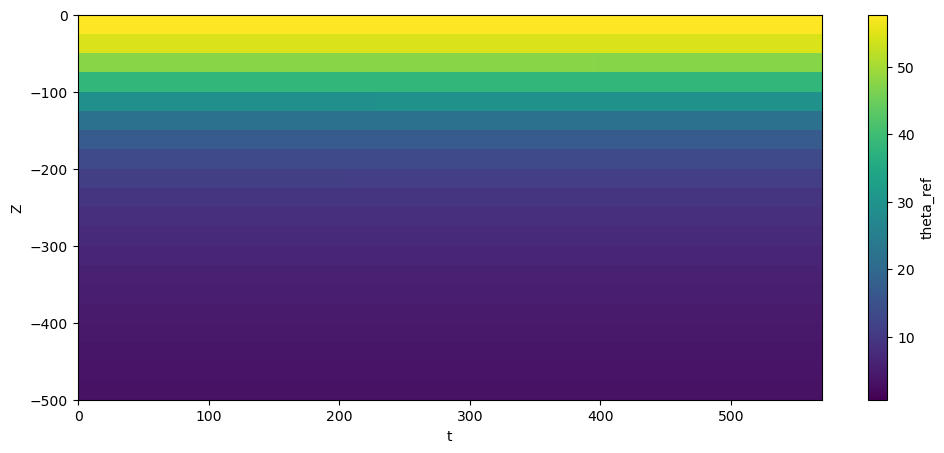

In [ ]:
plt.figure(figsize=(12,5))
ds_tref.theta_ref.T.plot()
plt.ylim(-500,0)

In [ ]:
# GIF
# Create a GIF from the saved PNG images
itmax=96
idt=1
png_files = [f'{fig_folder}/temp_anom_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/temp_anom_animation_m2_v1.gif', mode='I',palettesize=64, duration=500.0, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/temp_anom_nimation_m2_v1.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 97 frames at 'exp8_results/temp_z5_exp8/temp_anom_nimation_m2_v1.gif'


In [ ]:
# MP4
# Create an MP4 from the saved PNG images
# fig_folder = 'exp4_results/eta_exp4_2timesN2_M2_dt5s_v1'
itmax=193
idt=1
png_files = [f'{fig_folder}/temp_anom_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the mp4 (1 second per frame = 1 fps)
    with imageio.get_writer(f'{fig_folder}/temp_anom_animation_m2_v1.mp4', fps=1.5, codec='libx264') as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created MP4 with {len(existing_files)} frames at '{fig_folder}/temp_anom_animation_m2_v1.mp4'")
else:
    print("No PNG files found to create MP4.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 700) to (800, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Created MP4 with 95 frames at 'case_N2_fac_075/temp_anom_animation_m2_v1.mp4'


# get elevation data

[12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.
 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.
 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83.
 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96.]


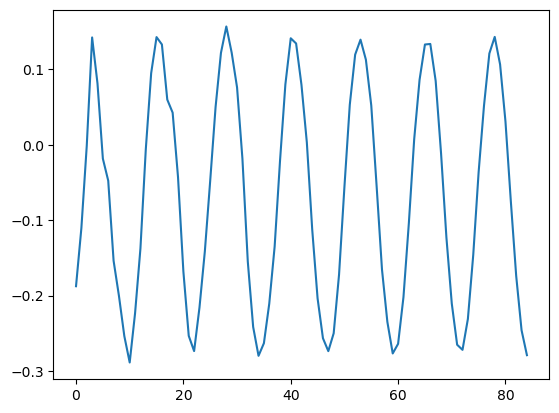

In [ ]:
ttseries = (ds_eta.time.values*5/np.timedelta64(1, 'h'))[12:]
etseries = ds_eta.ETAN.isel(XC=2,YC=1000).values[12:]
plt.plot(etseries)
# etseries = ds_eta.ETAN.isel(XC=20,YC=1000).values[20:]
# plt.plot(etseries)
# etseries = ds_eta.ETAN.isel(XC=200,YC=1000).values[20:]
# plt.plot(etseries)

print(ttseries)

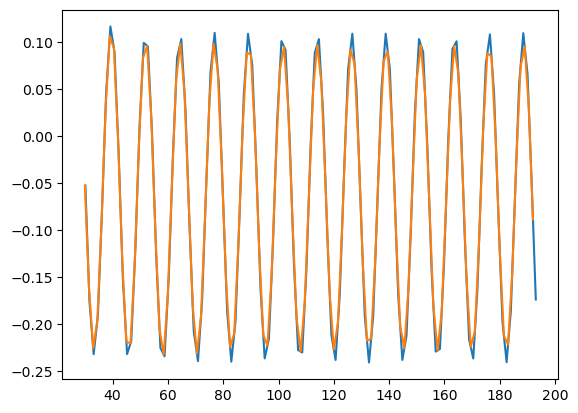

In [ ]:
t1 = np.arange(30,193,1.5)
etseries_interp = np.interp(t1,ttseries, etseries)
plt.plot(ttseries, etseries)
plt.plot(t1,etseries_interp)

In [ ]:
temp100 = ds_sn.THETA.isel(Z=5)
temp_t = temp100.isel(XC=2,YC=1000)
temp_t2 = temp100.isel(XC=200,YC=1000)

In [ ]:
# ttseries = (ds_eta.time.values*100/np.timedelta64(1, 'h'))
# plt.plot(ttseries,temp_t)
# plt.plot(ttseries,temp_t2)
# ttseries

temp_t.plot()
temp_t2.plot()

In [ ]:

@contextmanager
def suppress_stdout():
    """Context manager to suppress printing to standard output."""
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# t1 = np.arange(30,193,1.5)
# ttseries = (ds_sn.time.values*100/np.timedelta64(1, 'h'))[12:]
# t = np.arange(0, 30*24, 1)   # 30 days hourly
# # t = pd.to_datetime(np.arange(0, 100*24, 0.5), unit='h', origin='2023-01-01')

# # Two tidal constituents: M2 (12.42h), S2 (12.00h)
# # signal = 1.5 * np.cos(2*np.pi*t.hour/12.42) + 0.5 * np.cos(2*np.pi*t.hour/12.0 + np.pi/4)
# signal = 2.5 * np.cos(2*np.pi*t/12.42)
amp_m2_model = np.zeros((1520,1908))
pha_m2_model = np.zeros((1520,1908))
for ii in range(0,1908,20):
    print(ii)
    for jj in range(0,1520,20):
        etseries = ds_eta.ETAN.isel(XC=jj,YC=ii).values[12:]
        # etseries_interp = np.interp(t1,ttseries, etseries)
        with suppress_stdout():
            # Any print statements within this block will be suppressed
            xout = tt.t_tide(etseries,dt=1,constitnames=['M2'])
    
        amp_m2_model[jj,ii] = xout['tidecon'][0][0]
        pha_m2_model[jj,ii] = xout['tidecon'][0][2]

0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480
500
520
540
560
580
600
620
640
660
680
700
720
740
760
780
800
820
840
860
880
900
920
940
960
980
1000
1020
1040
1060
1080
1100
1120
1140
1160
1180
1200
1220
1240
1260
1280
1300
1380
1400
1420
1440
1460
1480
1500
1520
1540
1560
1580
1600
1620
1640
1660
1680
1700
1720
1740
1760
1780
1800
1820
1840
1860
1880
1900


In [ ]:
lontide = ds_sn.XC.values[0:1520:20]
lattide = ds_sn.YC.values[0:1908:20]

amp_m2 = xr.DataArray(
        amp_m2_model[0:1520:20,0:1908:20].T,
        coords={'y': lattide, 'x': lontide},
        dims=['y', 'x'],
        name='amp_m2'
    )
pha_m2 = xr.DataArray(
        pha_m2_model[0:1520:20,0:1908:20].T,
        coords={'y': lattide, 'x': lontide},
        dims=['y', 'x'],
        name='pha_m2'
    )
ds_tide = xr.merge([amp_m2, pha_m2])
ds_tide.to_netcdf('amp_pha_m2_model_res100_ctrl.nc')

Text(0.5, 1.0, 'Model M2 Tidal Amplitude (m)')

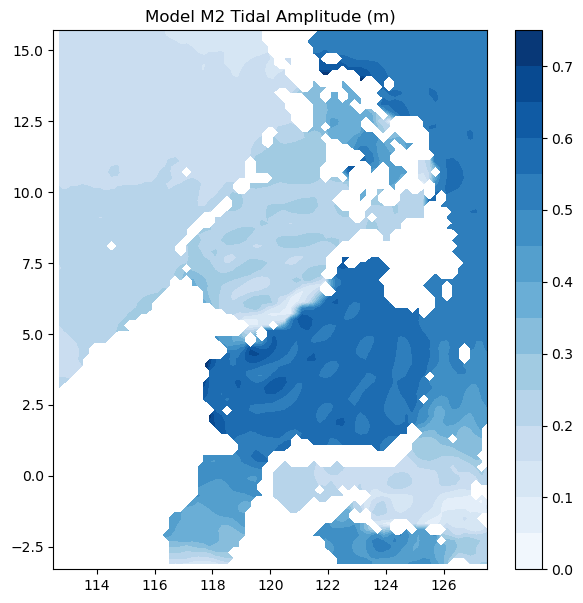

In [ ]:
# ds_tide.amp_m2.where(ds_tide.pha_m2!=0).plot.contourf(levels=np.arange(0,0.8,0.05),vmax=0.75)

plt.figure(figsize=(7,7))
plt.contourf(lontide,lattide,ds_tide.amp_m2.where(ds_tide.pha_m2!=0),levels=np.arange(0,0.8,0.05),vmax=0.75,cmap='Blues')
plt.colorbar()
plt.title('Model M2 Tidal Amplitude (m)')
# plt.contour(lontide,lattide,ds_tide.amp_m2.where(ds_tide.pha_m2!=0),levels=np.arange(0,0.8,0.1),colors='k')

Text(0.5, 1.0, 'Model M2 Tidal Phase (degree)')

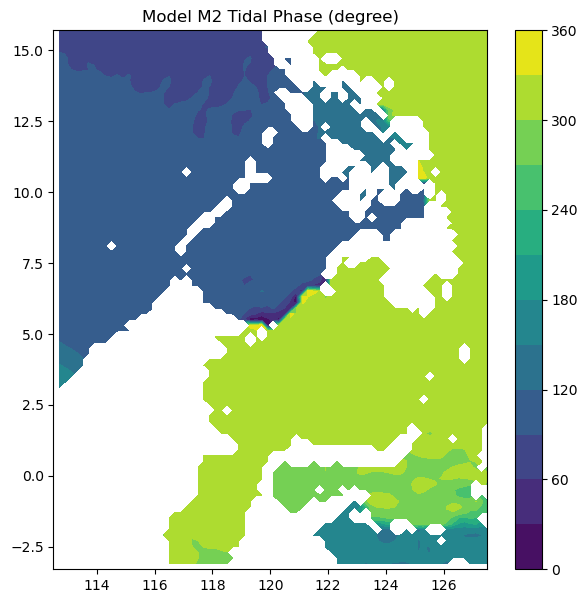

In [ ]:
pha_plt = ds_tide.pha_m2.where(ds_tide.pha_m2!=0).values
# pha_plt2 = ds_tide.pha_m2.where(ds_tide.pha_m2!=0)
# pha_plt2[pha_plt<180] = pha_plt+180
# pha_plt2[pha_plt>=180] = pha_plt-180
pha_plt2 = np.where(pha_plt<210,pha_plt+150,pha_plt-210)
# pha_plt2 = pha_plt2.where(pha_plt>=180,pha_plt-180)

# ds_tide.pha_m2.where(ds_tide.pha_m2!=0).plot(levels=np.arange(0,375,30))
plt.figure(figsize=(7,7))
plt.contourf(lontide,lattide,pha_plt2,levels=np.arange(0,375,30))
plt.colorbar()
plt.title('Model M2 Tidal Phase (degree)')

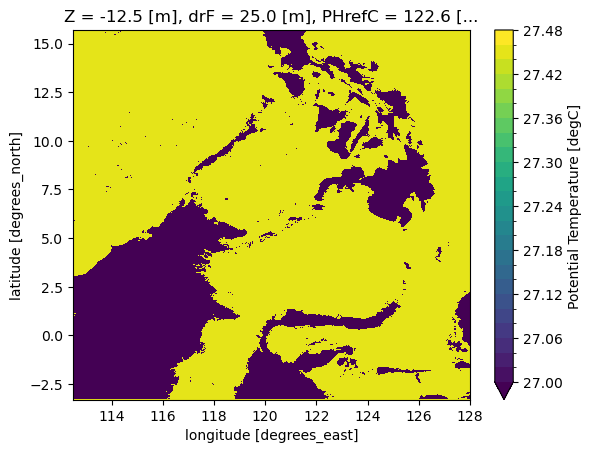

In [ ]:
ds_sn.THETA.isel(time=0,Z=0).plot(levels=np.arange(27,27.5,0.02))

(116.0, 122.0)

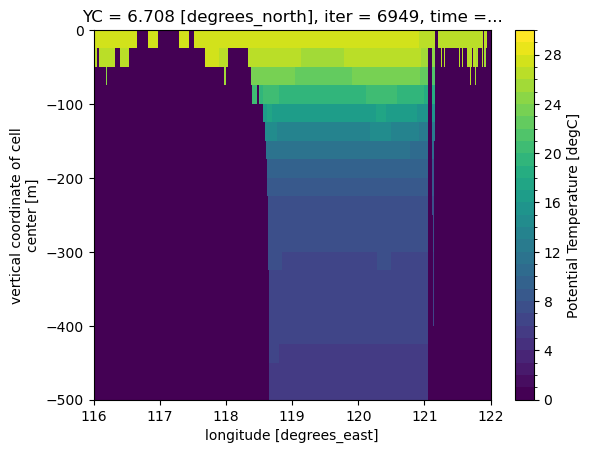

In [ ]:
ds_sn.THETA.isel(time=128,YC=600).plot.pcolormesh(levels = np.arange(0,31,1))
plt.ylim(-500,0)
plt.xlim(116,122)

# vertical sections

In [ ]:
x0 = np.linspace(112.508333333333333,127.99166666666666667,930)
y0 = np.linspace(-3.2916666666666667,15.691666666666666667,1140)
xmodel,ymodel = np.meshgrid(x0,y0)

In [ ]:
from scipy.interpolate import RegularGridInterpolator
spacing = 0.005  # about 0.3 minutes

theta_sec_tseries = []
for it in range(129):
    print(it)
    theta_sec1 = []
    for ik in range(57):
    
        t0 = ds_sn.THETA.isel(time=it, Z=ik).values.T
        t0[t0==0] = np.nan
        interp_func = RegularGridInterpolator((x0,y0), t0)
        
        # Section 1: (118°E, 10°N) to (121°E, 6°N)
        xsec1 = np.arange(118.5, 121+spacing, spacing)
        ysec1 = np.arange(9.333333333333334, 6-spacing, -spacing)
        if len(xsec1) != len(ysec1):
            points_needed = min(len(xsec1), len(ysec1))
            xsec1 = np.linspace(118.5, 121, points_needed)
            ysec1 = np.linspace(9.333333333333334, 6, points_needed)
        pts_sec1 = (xsec1, ysec1)
        
        theta_sec1.append(interp_func(pts_sec1))
    theta_sec1 = np.array(theta_sec1)
    theta_sec_tseries.append(theta_sec1)
theta_sec1_tseries = np.array(theta_sec1_tseries)

# distances_sec1 = np.sqrt((xsec1-xsec1[0])**2 + (ysec1-ysec1[0])**2) * 111

# # Extract water depths along each section directly from toposulu dataset
# depths_sec1 = np.zeros((57,len(xsec1)))

# # For each point in each section, find the nearest data point in toposulu
# for ik in range(57):
#     print(ik)
#     for i in range(len(xsec1)):
#         depths_sec1[ik,i] = ds_sn.THETA.isel(time=-1, Z=ik).sel(XC=xsec1[i], YC=ysec1[i], method='nearest').values

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128


In [ ]:
theta_sec1 = np.array(theta_sec1)

(-500.0, 0.0)

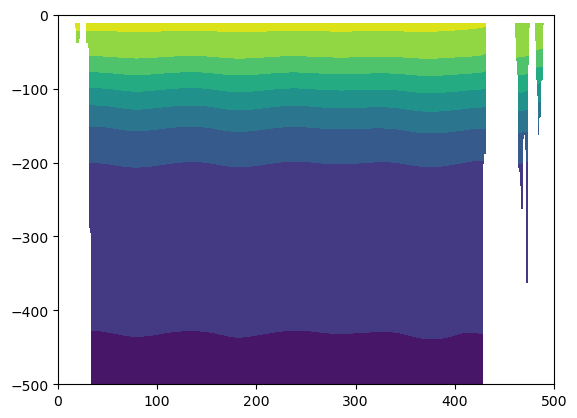

In [ ]:
plt.contourf(range(len(xsec1)),ds_sn.Z,theta_sec1)
plt.ylim(-500,0)

# vertical profile in Sulu

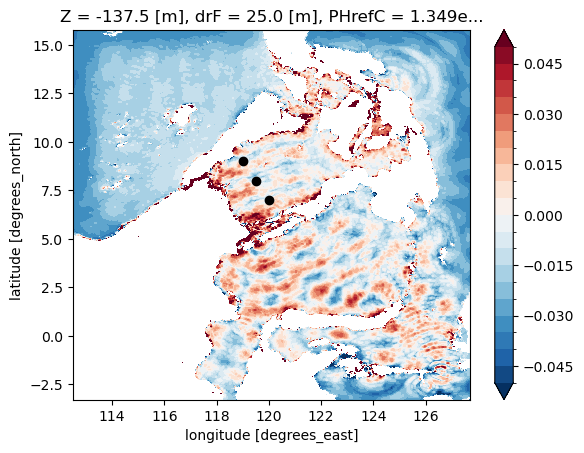

In [ ]:
(t_case.isel(time=190).where(t_case.isel(time=it)!=0)-tref.isel(t=190)).plot.contourf(levels=np.arange(-0.05,0.052,0.005))
plt.plot(120,7,'ok')
plt.plot(119.5,8,'ok')
plt.plot(119,9,'ok')

In [ ]:
ncase = ['075','033','050','150','200','250']
nt = 570

prf_folder = f'case_ctrl/profiles/'
    
try:
    os.makedirs(prf_folder, exist_ok=True)
    print(f"Folder '{prf_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{prf_folder}' : {e}.")
    
for it in tqdm(range(nt)):
    ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/',read_grid=False, 
                                   prefix=['outs_sn'], iters=[it*180])
    ds_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750)
    ds_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700)
    ds_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650)

    ds_profile1.to_netcdf(f'{prf_folder}profile1_yc1030_xc750.nc')
    ds_profile2.to_netcdf(f'{prf_folder}profile2_yc1130_xc700.nc')
    ds_profile3.to_netcdf(f'{prf_folder}profile3_yc1230_xc650.nc')


for icase in ncase:

    prf_folder = f'case_N2_fac_{icase}/profiles/'
    
    try:
        os.makedirs(prf_folder, exist_ok=True)
        print(f"Folder '{prf_folder}' created.")
    except OSError as e:
        print(f"Error creating dir '{prf_folder}' : {e}.")
        
    for it in tqdm(range(nt)):
        ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                       prefix=['outs_sn'], iters=[it*180])
        ds_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750)
        ds_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700)
        ds_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650)
    
        ds_profile1.to_netcdf(f'{prf_folder}profile1_yc1030_xc750.nc')
        ds_profile2.to_netcdf(f'{prf_folder}profile2_yc1130_xc700.nc')
        ds_profile3.to_netcdf(f'{prf_folder}profile3_yc1230_xc650.nc')


Folder 'case_ctrl/profiles/' created.


100%|██████████| 570/570 [2:02:59<00:00, 12.95s/it]  


Folder 'case_N2_fac_075/profiles/' created.


100%|██████████| 570/570 [1:59:54<00:00, 12.62s/it]  


Folder 'case_N2_fac_033/profiles/' created.


100%|██████████| 570/570 [1:53:47<00:00, 11.98s/it]


Folder 'case_N2_fac_050/profiles/' created.


  1%|          | 3/570 [00:32<1:47:26, 11.37s/it]

In [ ]:
prf_folder = f'case_N2_fac_{icase}/profiles/'

try:
    os.makedirs(prf_folder, exist_ok=True)
    print(f"Folder '{prf_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{prf_folder}' : {e}.")

ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                   prefix=['outs_sn'])

# t_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750).THETA.values
# t_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700).THETA.values
t_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650).THETA.values

# t_profile1 = np.array(t_profile1)
# t_profile2 = np.array(t_profile2)
t_profile3 = np.array(t_profile3)

# np.save(f'case_N2_fac_{icase}/profiles/temp_profile1_yc1030_xc750.pny',t_profile1)
# np.save(f'case_N2_fac_{icase}/profiles/temp_profile2_yc1130_xc700.pny',t_profile2)
np.save(f'case_N2_fac_{icase}/profiles/temp_profile3_yc1230_xc650.pny',t_profile3)

Folder 'case_N2_fac_075/profiles/' created.


In [ ]:
ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                   prefix=['outs_sn'])
print('U profile 1')
u_profile1 = ds_0.isel(j=1030,i_g=750).UVEL.values
print('U profile 2')
u_profile2 = ds_0.isel(j=1130,i_g=700).UVEL.values
print('U profile 3')
u_profile3 = ds_0.isel(j=1230,i_g=650).UVEL.values
print('V profile 1')
v_profile1 = ds_0.isel(j_g=1030,i=750).VVEL.values
print('V profile 2')
v_profile2 = ds_0.isel(j_g=1130,i=700).VVEL.values
print('V profile 3')
v_profile3 = ds_0.isel(j_g=1230,i=650).VVEL.values

print('Save to npy files')
u_profile1 = np.array(u_profile1)
u_profile2 = np.array(u_profile2)
u_profile3 = np.array(u_profile3)
v_profile1 = np.array(v_profile1)
v_profile2 = np.array(v_profile2)
v_profile3 = np.array(v_profile3)

np.save(f'case_N2_fac_{icase}/profiles/uvel_profile1_yc1030_xc750.pny',u_profile1)
np.save(f'case_N2_fac_{icase}/profiles/uvel_profile2_yc1130_xc700.pny',u_profile2)
np.save(f'case_N2_fac_{icase}/profiles/uvel_profile3_yc1230_xc650.pny',u_profile3)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile1_yc1030_xc750.pny',v_profile1)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile2_yc1130_xc700.pny',v_profile2)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile3_yc1230_xc650.pny',v_profile3)

U profile 1


KeyboardInterrupt: 

In [ ]:
ds_0

<xarray.Dataset> Size: 2TB
Dimensions:  (time: 575, k: 57, j: 1908, i_g: 1520, j_g: 1908, i: 1520,
              k_l: 57, k_u: 57, k_p1: 58)
Coordinates:
    iter     (time) int64 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * i        (i) int64 12kB 0 1 2 3 4 5 6 ... 1513 1514 1515 1516 1517 1518 1519
  * i_g      (i_g) int64 12kB 0 1 2 3 4 5 6 ... 1514 1515 1516 1517 1518 1519
  * j        (j) int64 15kB 0 1 2 3 4 5 6 ... 1901 1902 1903 1904 1905 1906 1907
  * j_g      (j_g) int64 15kB 0 1 2 3 4 5 6 ... 1902 1903 1904 1905 1906 1907
  * k        (k) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_u      (k_u) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_l      (k_l) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_p1     (k_p1) int64 464B 0 1 2 3 4 5 6 7 8 ... 49 50 51 52 53 54 55 56 57
  * time     (time) timedelta64[ns] 5kB 00:00:00 00:03:00 ... 1 days 04:42:00
Data variables:
    UVEL     (time, k, j, i_g) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    VVEL     (time, k, j_g, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    WVEL     (time, k_l, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    THETA    (time, k, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    PHIHYD   (time, k, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm

In [ ]:
# temp_profile1 = ds_sn.THETA.isel(YC=1030,XC=750).values
# temp_profile2 = ds_sn.THETA.isel(YC=1130,XC=700).values
# temp_profile3 = ds_sn.THETA.isel(YC=1230,XC=650).values

In [ ]:
# temp_profile1.to_netcdf(f'case_N2_fac_{icase}/temp_profile1_yc1030_xc750.nc')
# temp_profile2.to_netcdf(f'case_N2_fac_{icase}/temp_profile2_yc1130_xc700.nc')
# temp_profile3.to_netcdf(f'case_N2_fac_{icase}/temp_profile3_yc1230_xc650.nc')

In [ ]:
zprofile = ds_sn.Z
tprofile = ds_sn.time

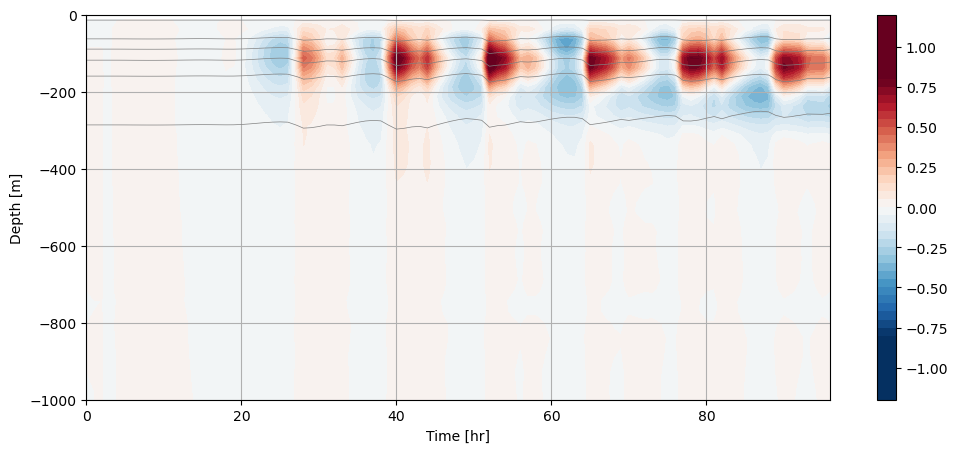

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile1-temp_profile1[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile1).T,colors='gray',linewidths=.5)

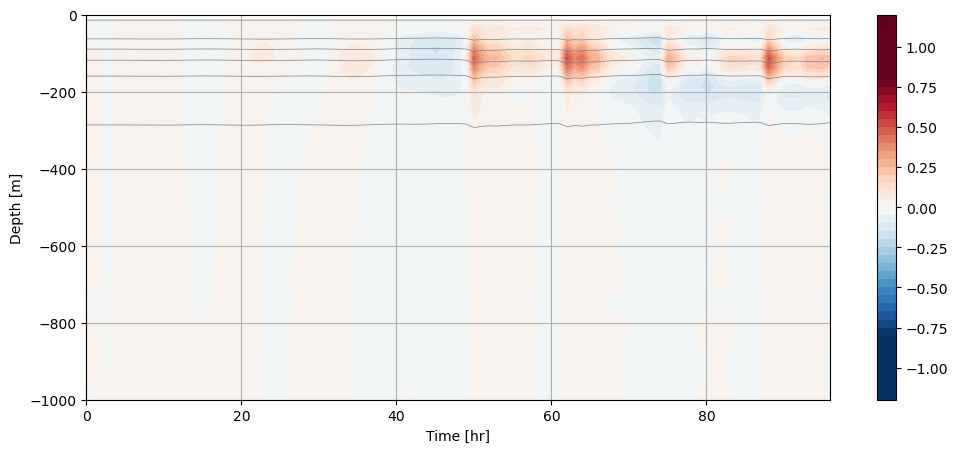

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile2-temp_profile2[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile2).T,colors='gray',linewidths=.5)

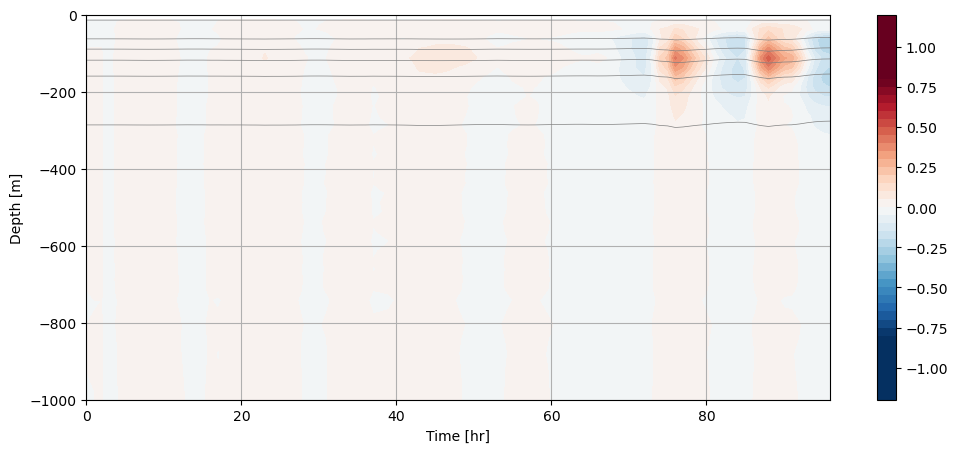

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile3-temp_profile3[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile3).T,colors='gray',linewidths=.5)
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')

## Vertical profile - v2

In [ ]:
# ds_profile1 = xr.open_dataset('exp7_results/temp_profile1_yc1030_xc750.nc')
# ds_profile2 = xr.open_dataset('exp7_results/temp_profile2_yc1130_xc700.nc')
# ds_profile3 = xr.open_dataset('exp7_results/temp_profile3_yc1230_xc650.nc')

# temp_profile1 = ds_profile1.THETA.values
# temp_profile2 = ds_profile2.THETA.values
# temp_profile3 = ds_profile3.THETA.values
t_case = ds_sn.THETA.isel(time = slice(0,nt),Z=5)
# tref
for it in tqdm(range(nt)):
    ds_tref0 = xr.open_dataset(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc')
    if it==0:
        ds_tref = ds_tref0
    else:
        ds_tref = xr.concat([ds_tref,ds_tref0],"t")

ds_tref['t'] = ds_sn.time[0:nt]
# ds_tref
tref = ds_tref.theta_ref
# ds_tref = xr.open_dataset('theta_ref/theta_ref_exp8_small_tide_0.01.nc')
# # ds_tref
# tref = ds_tref.theta_ref.values

tanom_to_tref_1 = t_profile1-tref
tanom_to_tref_2 = t_profile2[0:570,:]-tref
tanom_to_tref_3 = t_profile3[0:570,:]-tref

100%|██████████| 570/570 [00:05<00:00, 112.83it/s]


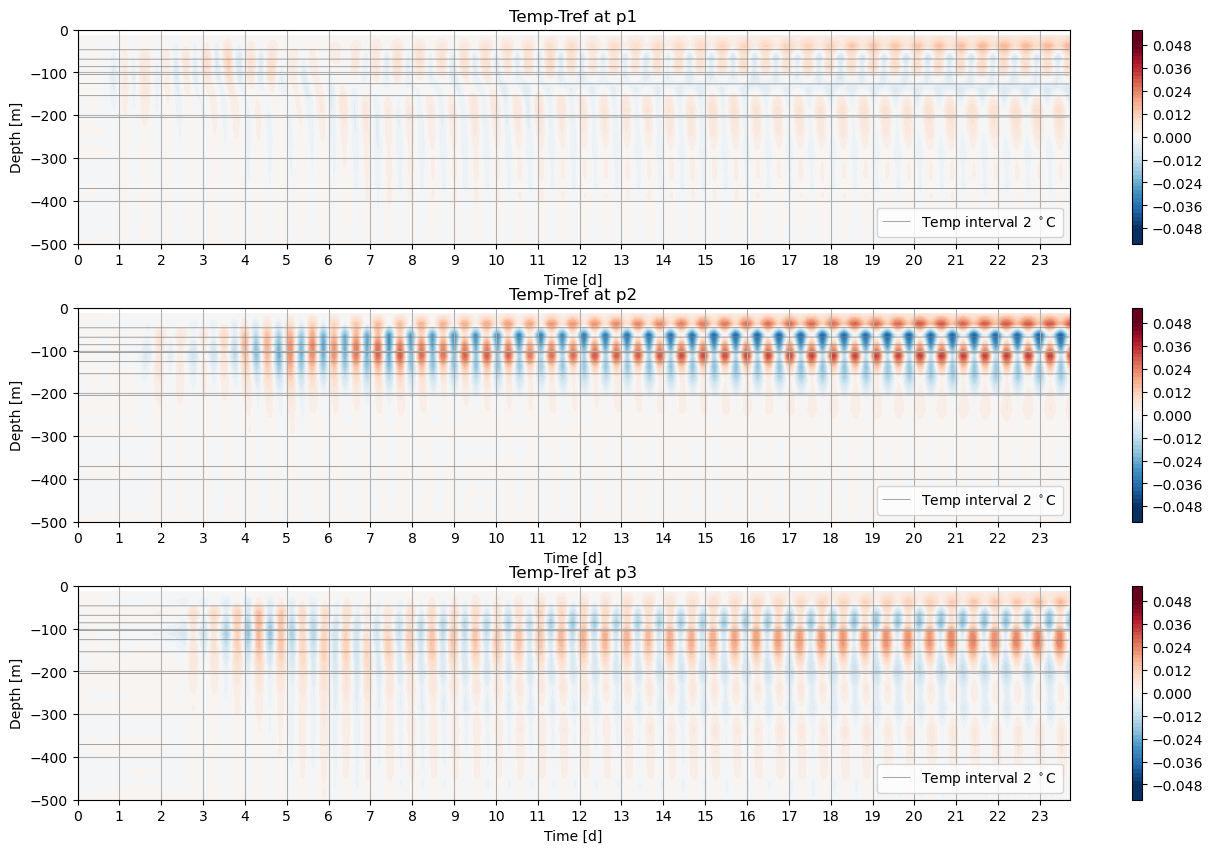

In [ ]:


figure, ax = plt.subplots(3,1,figsize=(16,10))
cnt2 = ax[0].contourf(np.arange(nt), zprofile, tanom_to_tref_1.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[0].set_ylim(-500,0)
ax[0].set_xticks(range(0,nt,24))
ax[0].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel('Depth [m]')
ax[0].grid('on')
figure.colorbar(cnt2,ax=ax[0])
cnt1 = ax[0].contour(np.arange(nt), zprofile, (t_profile1).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[0].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[0].set_title('Temp-Tref at p1')

cnt2 = ax[1].contourf(np.arange(nt), zprofile, tanom_to_tref_2.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[1].set_ylim(-500,0)
ax[1].set_xticks(range(0,nt,24))
ax[1].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel('Depth [m]')
ax[1].grid('on')
figure.colorbar(cnt2,ax=ax[1])
cnt1 = ax[1].contour(np.arange(nt), zprofile, (t_profile2[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[1].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[1].set_title('Temp-Tref at p2')

cnt2 = ax[2].contourf(np.arange(nt), zprofile, tanom_to_tref_3.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[2].set_ylim(-500,0)
ax[2].set_xticks(range(0,nt,24))
ax[2].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[2].set_xlabel('Time [d]')
ax[2].set_ylabel('Depth [m]')
ax[2].grid('on')
figure.colorbar(cnt2,ax=ax[2])
cnt1 = ax[2].contour(np.arange(nt), zprofile, (t_profile3[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[2].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[2].set_title('Temp-Tref at p3')
plt.subplots_adjust(hspace=0.3,)


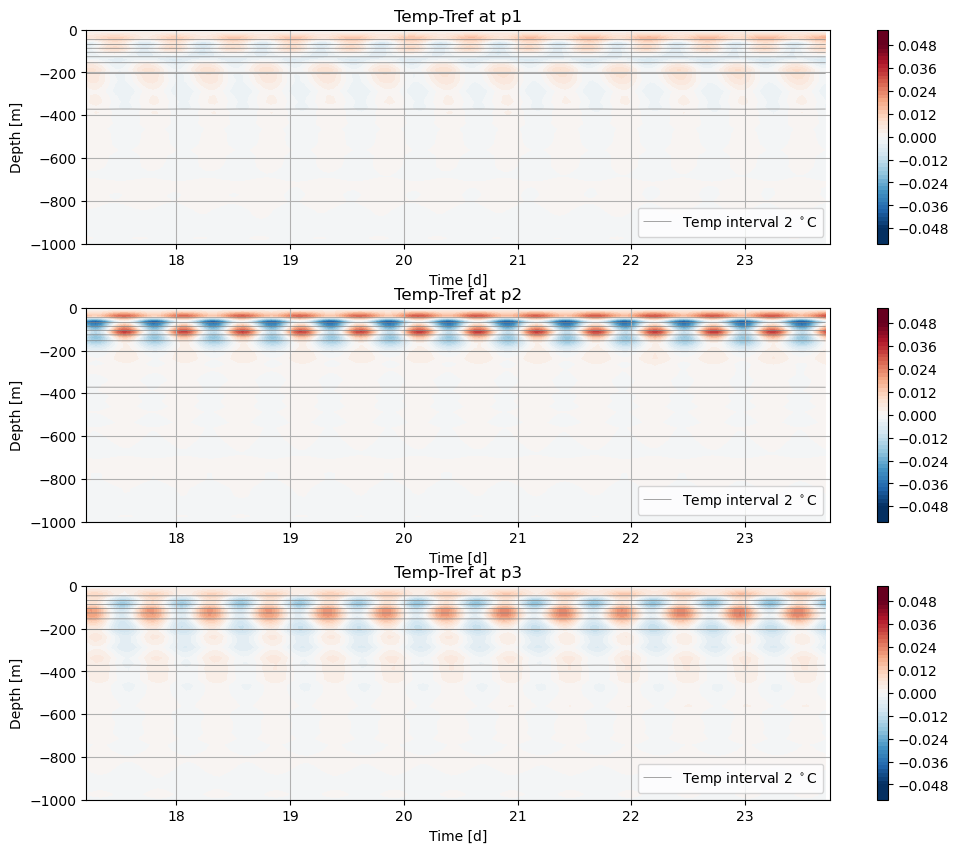

In [ ]:
figure, ax = plt.subplots(3,1,figsize=(12,10))
cnt2 = ax[0].contourf(np.arange(nt), zprofile, tanom_to_tref_1.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[0].set_ylim(-1000,0)
ax[0].set_xticks(range(0,nt,24))
ax[0].set_xticklabels(range(0,24,1))
ax[0].set_xlim(413,nt)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel('Depth [m]')
ax[0].grid('on')
figure.colorbar(cnt2,ax=ax[0])
cnt1 = ax[0].contour(np.arange(nt), zprofile, (t_profile1).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[0].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[0].set_title('Temp-Tref at p1')

cnt2 = ax[1].contourf(np.arange(nt), zprofile, tanom_to_tref_2.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[1].set_ylim(-1000,0)
ax[1].set_xticks(range(0,nt,24))
ax[1].set_xticklabels(range(0,24,1))
ax[1].set_xlim(413,nt)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel('Depth [m]')
ax[1].grid('on')
figure.colorbar(cnt2,ax=ax[1])
cnt1 = ax[1].contour(np.arange(nt), zprofile, (t_profile2[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[1].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[1].set_title('Temp-Tref at p2')

cnt2 = ax[2].contourf(np.arange(nt), zprofile, tanom_to_tref_3.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[2].set_ylim(-1000,0)
ax[2].set_xticks(range(0,nt,24))
ax[2].set_xticklabels(range(0,24,1))
ax[2].set_xlim(413,nt)
ax[2].set_xlabel('Time [d]')
ax[2].set_ylabel('Depth [m]')
ax[2].grid('on')
figure.colorbar(cnt2,ax=ax[2])
cnt1 = ax[2].contour(np.arange(nt), zprofile, (t_profile3[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[2].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[2].set_title('Temp-Tref at p3')
plt.subplots_adjust(hspace=0.3,)
